# Environmental Predictors of Child Obesity in London: A Supervised Machine Learning Analysis at MSOA Level

##### Preparation

- [Github link](https://github.com/pjmcn83/childhood-obesity-london)

- Number of words: 1,570

- Runtime: 5 minutes (*7.6 GB RAM, CPU Intel Core i5-1335U (13th Gen) - 12 core*) 

- Coding environment: Urban Spatial Science Podman (CPython 3.12.11 · IPython 9.4.0 · WSL2 Linux · 12 CPU cores · 7.6 GB RAM)

- License: This notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional libraries not included in standard SDS environment:
    - **xgboost** (3.2.0): Gradient boosted tree models for regression and classification
    - **imbalanced-learn** (0.14.1): SMOTE implementation for handling imbalanced classification targets

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

Childhood obesity remains one of the most significant public health challenges in the UK. The National Child Measurement Programme (NCMP) reports childhood obesity among Year 6 children in London being higher than the national average (NHS England, 2025). Socio-economic deprivation is the most documented predictor of childhood obesity, with children in most deprived area significantly more likely to be obese than those in least deprived areas (Rahilly et al., 2025). The built environment has received increased attention, particularly the proximity to fast food premises (Burgoine et al., 2014), access to public green space supporting active lifestyles (Jia et al., 2020) and public transport accessibility (Xu et al., 2020). Research findings in these areas are generally mixed providing an interesting topic to examine across London. 

This analysis uses supervised machine learning at Middle Super Output Area (MSOA) level to examine the role fast food availability, green space and public transport accessibility play in predicting child obesity rates once socioeconomic deprivation are controlled for.

## 2. Research question

[[ go back to the top ]](#Table-of-contents)

*To what extent do the environmental factors of fast food establishment density, access to public green space and public transport accessibility predict childhood obesity rates across London MSOAs, and do these effects persist once controlling for socio-economic deprivation?*

## 3. Data

[[ go back to the top ]](#Table-of-contents)

<figure id="table-1">
<figcaption><strong>Table 1:</strong> Dataset variables, types, descriptions and notes. Variables are categorised as the dependent outcome (Y), primary environmental predictors (X), and area-level controls (X).</figcaption>
<br>


| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| child_obesity_rate                  | Numeric      | Percentage of Year 6 children classified as obese within each MSOA.     | Dependent Variable (Y).  |
| fast_food_density                   | Numeric      | Number of takeaway establishments per square kilometer ($km^2$).        | Environmental predictor (X). Calculated via spatial join and area normalisation.  |
| avg_size_green_1km_m2               | Numeric      | Average size ($m^2$) of the public green space within 1km.              | Environmental predictor (X). Source data captured at LSOA level so aggregated to MSOA.   |
| employment_score                    | Numeric      | IMD 2025 score related to MSOA employment levels.                       | Deprivation controls (X). Sourced from IMD 2025 |
| education_score                     | Numeric      | IMD 2025 score related to MSOA education levels.                        | Deprivation controls (X). Sourced from IMD 2025 |
| crime_score                         | Numeric      | IMD 2025 score related to MSOA crime levels.                            | Deprivation controls (X). Sourced from IMD 2025 |
| idaci_score                         | Numeric      | Income Deprivation Affecting Children Index, taken from IMD 2025        | Deprivation controls (X). Sourced from IMD 2025. Child specific deprivation measure.  |
| ptal_accessibility_index            | Numeric      | Public Transport Accessibility Level (PTAL) score.                      | Environmental predictor (X). Data sourced from TfL  |
| BNG_east                            | Numeric      | MSOA centroid easting in British National Grid (metres).                | Used for spatial weights for KNN imputation and spatial modeling.  |
| BNG_north                           | Numeric      | MSOA centroid northing in British National Grid (meters).               | Used as spatial weights for KNN imputation and spatial modeling.  |

</figure>

Childhood obesity rates are captured by NCMP via the Fingertips API, filtered to London MSOAs. Year 6 obesity prevalence rate (Indicator: 93107) is used in preference to Reception data as older children have greater independent mobility, making the local food and built environment more directly relevant to daily behaviours than younger children whose activities remain parent dependent (Page et al., 2010). 

The master dataset combines variables drawn from multiple sources ([Table 1](#table-1)) preprocessed in a companion notebook hosted in [GitHub](https://github.com/pjmcn83/childhood-obesity-london/blob/main/child-obesity-data-prep.ipynb). 

The key environmental variables are: 
- fast_food_density: derived by spatially joining FHRS premises locations to MSOA boundaries and normalising by MSOA area in km²
- avg_size_green_1km_m2: available at LSOA level so values are aggregated to MSOA using the area-weighted means.
- ptal_accessibility_index: captures public transport provision in a local area. 

Deprivation controls are sourced from the IMD as the primary driver for obesity (Rahilly et al., 2025). Four IMD scores, employment, education, crime and IDACI, are retained to capture distinct elements of deprivation, with IDACI included as the child-specific measure relevant to the outcome. 

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

<figure>
<img src="./images/methodology-diagram.png" alt="Methodology flowchart showing data sources, preprocessing, model tasks, interpretation and spatial validation stages"/>
<figcaption style="font-size: 0.85em; color: gray;">
<strong>Figure 1:</strong> Methodology flowchart illustrating the pipeline from data sources through preprocessing, regression and classification tasks, model interpretation and cross-validation to outputs.</figcaption>
</figure>

### 4.0 Dependencies

In [1]:
# install dependencies if required
#!pip install xgboost==3.2.0 imbalanced-learn==0.14.1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modelling
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.cluster import KMeans

# Imbalanced data
from imblearn.over_sampling import SMOTE

print('All dependencies loaded successfully.')
print(f'  xgboost:          {__import__("xgboost").__version__}')
print(f'  imbalanced-learn: {__import__("imblearn").__version__}')
print(f'  scikit-learn:     {__import__("sklearn").__version__}')

All dependencies loaded successfully.
  xgboost:          3.2.0
  imbalanced-learn: 0.14.1
  scikit-learn:     1.7.2


### 4.1 Preprocessing

Preprocessing has been handled in a separate notebook available from [GitHub](https://github.com/pjmcn83/childhood-obesity-london/blob/main/child-obesity-data-prep.ipynb), to maintain focus on the analytical methods.

#### 4.1.1 Dropping, Imputation and Scaling

`child_obesity_rate` contained 22 NaNs from unmet NCMP reporting thresholds. As the target variable these are dropped rather than imputed as imputing using the model features would artificially inflate model performance by introducing circular dependency between predictors and outcome.

`avg_size_green_1km_m2` contained 39 missing values imputed using `KNNImputer` (k=5). Features were standardised using `StandardScaler` to prevent coordinates dominating the distance metric. Values are then transformed back to original units.

### 4.2 Preparation: Data Load

In [3]:
# ── Load from GitHub (update URL to your own repo before submission) ──────────
GITHUB_RAW_URL = "https://raw.githubusercontent.com/pjmcn83/childhood-obesity-london/refs/heads/main/data/processed/london_obesity_master_dataset.csv"

df = pd.read_csv(GITHUB_RAW_URL)

#### 4.2.1 *log transforms*

`fast_food_density` (skew = 4.94) and `avg_size_green_1km_m2` (skew = 6.27) are heavily right-skewed. Whilst XGBoost is scale-invariant, extreme skew concentrates split budget in the extreme tail. A log1p transform improves splits across the full feature.

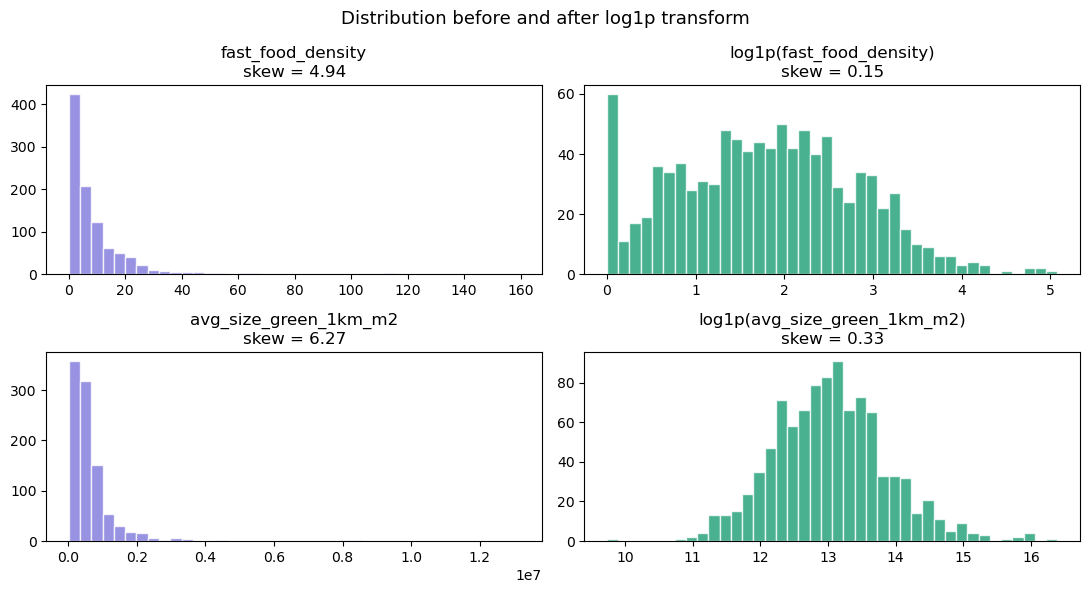

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
fig.suptitle('Distribution before and after log1p transform', fontsize=13)

for i, col in enumerate(['fast_food_density', 'avg_size_green_1km_m2']):
    axes[i, 0].hist(df[col], bins=40, color='#7F77DD', alpha=0.8, edgecolor='white')
    axes[i, 0].set_title(f'{col}\nskew = {df[col].skew():.2f}')
    axes[i, 1].hist(np.log1p(df[col]), bins=40, color='#1D9E75', alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'log1p({col})\nskew = {np.log1p(df[col]).skew():.2f}')

plt.tight_layout()
plt.show()

# Apply transforms
df['fast_food_density_log']       = np.log1p(df['fast_food_density'])
df['avg_size_green_1km_m2_log']   = np.log1p(df['avg_size_green_1km_m2'])

#### 4.2.2 Features and targets

Two parallel tasks are constructed from the same dataset:

- **Regression (Task A):** predict continuous `child_obesity_rate` answering *how much* each feature contributes.
- **Classification (Task B):** predict whether MSOAs fall in the top 10% (≥ 30.78%), indentifying *at-risk* areas and introducing the 9:1 class imbalance problem.

In [5]:
# --- Feature matrix ---
# BNG coordinates are retained as spatial features — XGBoost can learn
# the east-west deprivation gradient from coordinates alone.
# msoa_code is an ID variable and must be excluded.

FEATURES = [
    'fast_food_density_log',       # primary environmental predictor
    'avg_size_green_1km_m2_log',   # green space access
    'idaci_score',                 # child-specific deprivation
    'employment_score',            # IMD sub-domain
    'education_score',             # IMD sub-domain
    'crime_score',                 # IMD sub-domain
    'ptal_accessibility_index',    # transport accessibility
    'BNG_east',                    # spatial feature
    'BNG_north',                   # spatial feature
]

# --- Targets ---
y_reg  = df['child_obesity_rate']  # Task A: regression

THRESHOLD = df['child_obesity_rate'].quantile(0.90) # top 10%
y_clf  = (df['child_obesity_rate'] >= THRESHOLD).astype(int) # Task B: classification

X = df[FEATURES]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'\nRegression target  — mean: {y_reg.mean():.1f}%, std: {y_reg.std():.1f}%')
print(f'Classification target — threshold: {THRESHOLD:.2f}%')
print(f'  Class 0 (normal):  {(y_clf==0).sum()} MSOAs')
print(f'  Class 1 (extreme): {(y_clf==1).sum()} MSOAs')
print(f'  Imbalance ratio:   {(y_clf==0).sum() / (y_clf==1).sum():.1f} : 1')

Features (9): ['fast_food_density_log', 'avg_size_green_1km_m2_log', 'idaci_score', 'employment_score', 'education_score', 'crime_score', 'ptal_accessibility_index', 'BNG_east', 'BNG_north']

Regression target  — mean: 23.3%, std: 6.3%
Classification target — threshold: 30.78%
  Class 0 (normal):  882 MSOAs
  Class 1 (extreme): 98 MSOAs
  Imbalance ratio:   9.0 : 1


#### 4.2.3 Outcome distribution

Outcome distribution confirms class imbalance and justifies the 10% classification threshold applied ([section 4.3.2](#432-task-b---xgboost-classification)) and imbalanced data handling ([section 4.2.6](#426-imbalance-data-handling)).

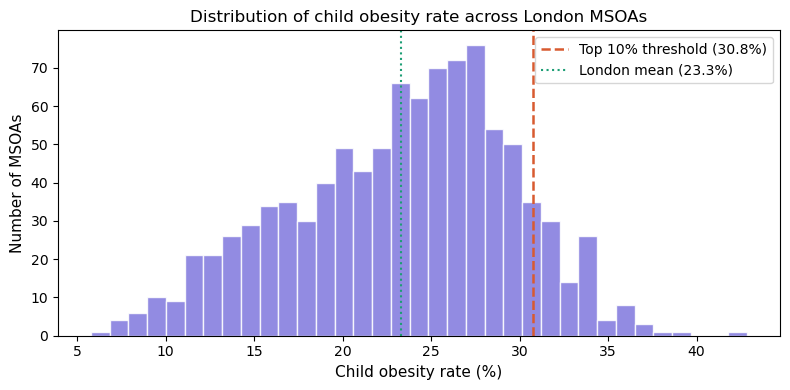

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_reg, bins=35, color='#7F77DD', alpha=0.85, edgecolor='white')
ax.axvline(THRESHOLD, color='#D85A30', linewidth=1.8, linestyle='--',
           label=f'Top 10% threshold ({THRESHOLD:.1f}%)')
ax.axvline(y_reg.mean(), color='#1D9E75', linewidth=1.5, linestyle=':',
           label=f'London mean ({y_reg.mean():.1f}%)')
ax.set_xlabel('Child obesity rate (%)', fontsize=11)
ax.set_ylabel('Number of MSOAs', fontsize=11)
ax.set_title('Distribution of child obesity rate across London MSOAs', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### 4.2.4 Spatial distribution

High obesity MSOAs cluster in inner East London rather than being randomly distributed, justifying the inclusion of coordinates as model features and the use of spatial k-fold CV ([section 4.5](#45-spatial-k-fold-cross-validation)).

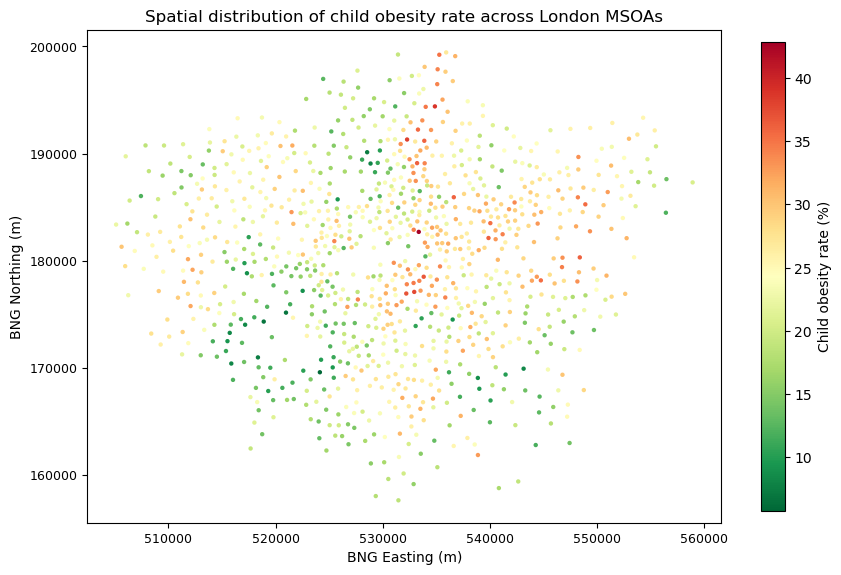

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    df['BNG_east'], df['BNG_north'],
    c=y_reg, cmap='RdYlGn_r',
    s=10, alpha=1, linewidths=0
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Child obesity rate (%)', fontsize=10)
ax.set_aspect('equal')
ax.set_title('Spatial distribution of child obesity rate across London MSOAs', fontsize=12)
ax.set_xlabel('BNG Easting (m)', fontsize=10)
ax.set_ylabel('BNG Northing (m)', fontsize=10)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

#### 4.2.5 Train/test split

A stratified 80/20 preserves minority class ration in train and test sets This is replaced with spatial k-fold CV in [section 4.5](#45-spatial-k-fold-cross-validation) to produce a more honest generalisation.

In [8]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf # preserve class ratio in both splits
)

print(f'Train: {X_train.shape[0]} MSOAs | Test: {X_test.shape[0]} MSOAs')
print(f'Train minority class: {y_clf_train.sum()} ({y_clf_train.mean()*100:.1f}%)')
print(f'Test  minority class: {y_clf_test.sum()}  ({y_clf_test.mean()*100:.1f}%)')

Train: 784 MSOAs | Test: 196 MSOAs
Train minority class: 78 (9.9%)
Test  minority class: 20  (10.2%)


#### 4.2.6 Imbalanced data handling - SMOTE

The classification target's 9:1 class imbalance (882 normal/98 extreme MSOAs). Without correction modelling can achieve 90% accuracy by predicting every MSOA as normal whilst identifying no extreme cases.

SMOTE (Chawla et al., 2002) creates synthetic minority class examples to create a more diverse training set without duplication. `scale_pos_weight` and threshold tuning are additionally applied in [section 4.3.2](#432-task-b---xgboost-classification).

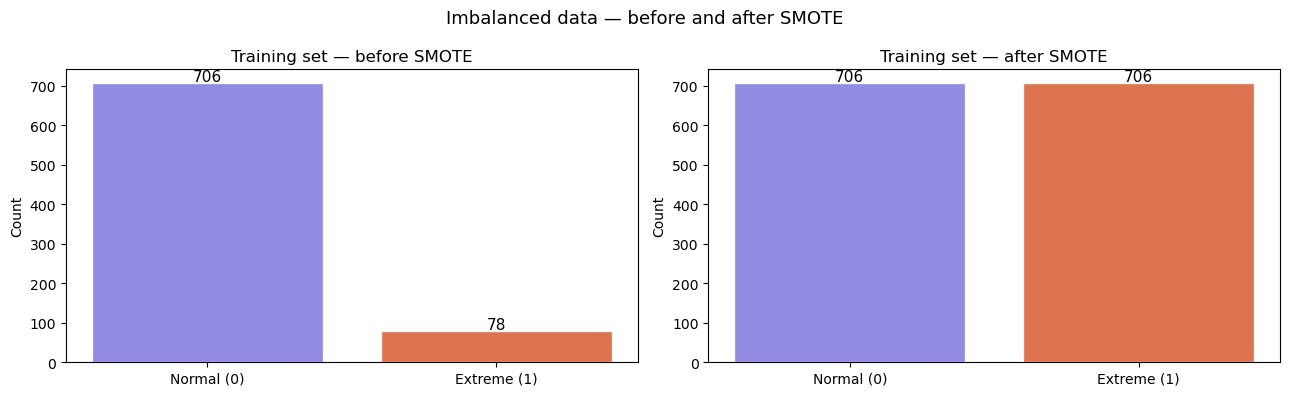

In [9]:
# ── Visualise the imbalance problem ────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Imbalanced data — before and after SMOTE', fontsize=13)

# Before SMOTE
counts_before = y_clf_train.value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Extreme (1)'], counts_before.values,
            color=['#7F77DD', '#D85A30'], alpha=0.85, edgecolor='white')
axes[0].set_title('Training set — before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_clf_train_smote = smote.fit_resample(X_train, y_clf_train)

# After SMOTE
counts_after = pd.Series(y_clf_train_smote).value_counts().sort_index()
axes[1].bar(['Normal (0)', 'Extreme (1)'], counts_after.values,
            color=['#7F77DD', '#D85A30'], alpha=0.85, edgecolor='white')
axes[1].set_title('Training set — after SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### 4.3 XGBoost

XGBoost (Chen & Guestrin, 2016) is selected as the primary model. As a tree-based method it makes threshold-based splits, so is unaffected by features at very different scales (coordinates vs deprivation indices). Built-in regularisation (`reg_alpha`, `reg_lambda`) prevents overfitting on the small sample (n=980).

#### 4.3.1 Task A - XGBoost Regression

Hyperparameters are selected via `GridSearchCV` testing tree depth, learning rate and number of estimators using 5 fold cross-validation, with optimal values dynamically set in the `XGBRegressor`.

The model predicts `child_obesity_rate` as a continuous outcome optimising for RMSE, evaluated on the test set using RMSE, MAE and R².

─── Regression results (test set) ───────────────────────
  RMSE : 3.343%
  MAE  : 2.621%
  R²   : 0.693


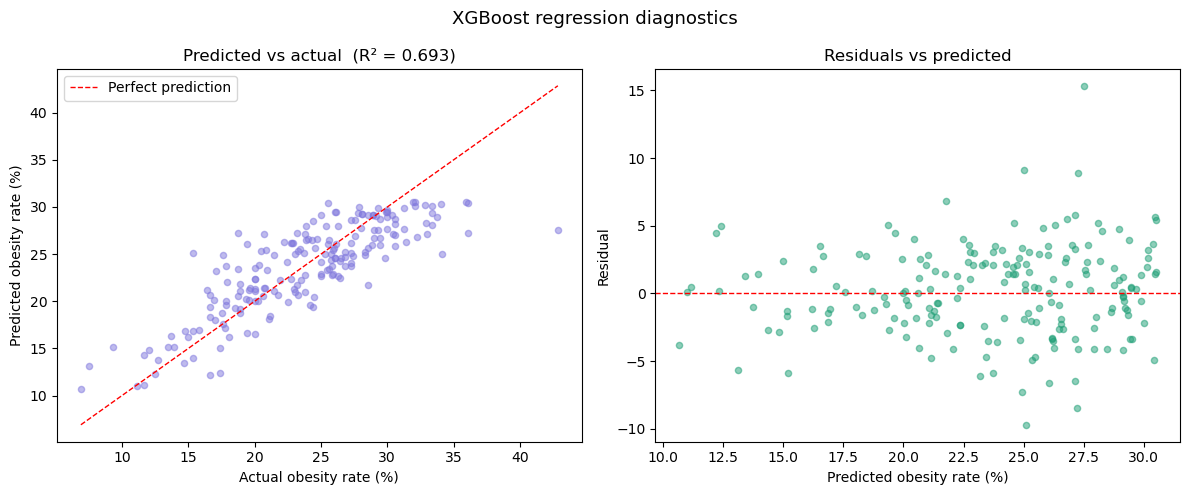

In [10]:
# ── XGBoost regression ───
# Hyperparameters set using GridSearchCV with 5-fold cross-validation on the training set.
param_grid = {
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators'  : [100, 200, 400]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_reg_train)

xgb_reg = XGBRegressor(
    **grid_search.best_params_,  # unpacks max_depth, learning_rate, n_estimators
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = 42,
    #early_stopping_rounds = max(10, grid_search.best_params_['n_estimators'] // 5), # commented out as caused fluctuations in results for submission, performance is better without this
    eval_metric         = 'rmse',
    verbosity           = 0
)

xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)

y_reg_pred = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─── Regression results (test set) ───────────────────────')
print(f'  RMSE : {rmse:.3f}%')
print(f'  MAE  : {mae:.3f}%')
print(f'  R²   : {r2:.3f}')
#print(f'  Best iteration: {xgb_reg.best_iteration}')

# ── Regression diagnostics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('XGBoost regression diagnostics', fontsize=13)

# Predicted vs actual
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.5, s=20, color='#7F77DD')
lims = [min(y_reg_test.min(), y_reg_pred.min()),
        max(y_reg_test.max(), y_reg_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual obesity rate (%)')
axes[0].set_ylabel('Predicted obesity rate (%)')
axes[0].set_title(f'Predicted vs actual  (R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.5, s=20, color='#1D9E75')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted obesity rate (%)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted')

plt.tight_layout()
plt.show()

#### 4.3.2 Task B - XGBoost Classification

Following [SMOTE resampling](#426-imbalanced-data-handling--smote), two further corrections are applied:

- `scale_pos_weight` - upweights minority class loss function, forcing model focus towards rare high risk MSOAs.
- Threshold tuning - sweeps 0.1-0.9 identifying the maximising value of F1 on the minority class, prioritsing recall of extreme cases over accuracy.

F1 is used to balance precision (avoiding false alarms) and recall (not missing real cases). Accuracy optimisation alone would overlook the most extreme MSOAs.

scale_pos_weight: 9.1 (neg=706, pos=78)
Optimal threshold: 0.61  (default was 0.50)

─── Classification results (test set) ───────────────────
  F1 score (minority class) : 0.473
  ROC-AUC                   : 0.862
  PR-AUC                    : 0.400
  Matthews Corr. Coef.      : 0.415

                     precision    recall  f1-score   support

         Normal (0)       0.96      0.88      0.91       176
Extreme obesity (1)       0.37      0.65      0.47        20

           accuracy                           0.85       196
          macro avg       0.66      0.76      0.69       196
       weighted avg       0.90      0.85      0.87       196



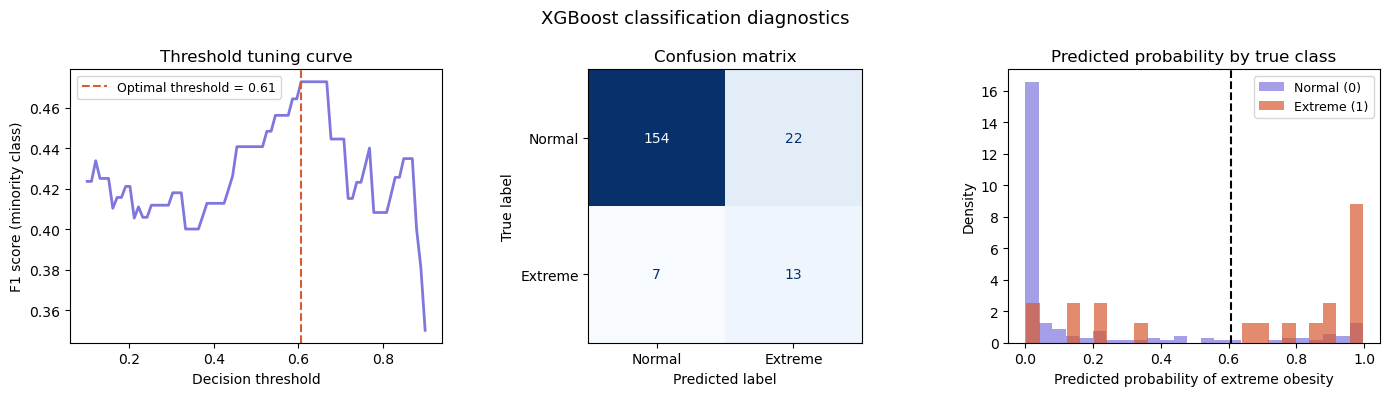

In [11]:
# --- GridsearchCV for classification ---
# A grid search could be used but test runs showed that it did not improve 
# performance compared to the original

# --- Compute class weight ---
neg = (y_clf_train == 0).sum()
pos = (y_clf_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.1f} (neg={neg}, pos={pos})')

# --- XGBoost classifier (trained on SMOTE data) ---
xgb_clf = XGBClassifier(
    n_estimators        = 400,
    max_depth           = 4,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    scale_pos_weight    = scale_pos_weight,
    random_state        = 42,
    #early_stopping_rounds = 30,  # commented out as caused fluctuations in results for submission, performance is better without this
    eval_metric         = 'aucpr',   # area under precision-recall — better than AUC for imbalanced
    verbosity           = 0
)

xgb_clf.fit(
    X_train_smote, y_clf_train_smote,
    eval_set=[(X_test, y_clf_test)],
    verbose=False
)

# --- Threshold tuning ---
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 80)
f1_scores  = [f1_score(y_clf_test, (y_proba >= t).astype(int), zero_division=0)
              for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_clf_pred     = (y_proba >= best_threshold).astype(int)

print(f'Optimal threshold: {best_threshold:.2f}  (default was 0.50)')

# --- Classification metrics ---
f1     = f1_score(y_clf_test, y_clf_pred)
roc    = roc_auc_score(y_clf_test, y_proba)
prauc  = average_precision_score(y_clf_test, y_proba)
mcc    = matthews_corrcoef(y_clf_test, y_clf_pred)

print('\n─── Classification results (test set) ───────────────────')
print(f'  F1 score (minority class) : {f1:.3f}')
print(f'  ROC-AUC                   : {roc:.3f}')
print(f'  PR-AUC                    : {prauc:.3f}')
print(f'  Matthews Corr. Coef.      : {mcc:.3f}')
print()
print(classification_report(y_clf_test, y_clf_pred,
      target_names=['Normal (0)', 'Extreme obesity (1)']))

# --- Classification diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('XGBoost classification diagnostics', fontsize=13)

# Threshold curve — completes the Phase 2 placeholder
axes[0].plot(thresholds, f1_scores, color='#7F77DD', linewidth=2)
axes[0].axvline(best_threshold, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Optimal threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('F1 score (minority class)')
axes[0].set_title('Threshold tuning curve')
axes[0].legend(fontsize=9)

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Extreme'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix')

# Probability distribution by class
axes[2].hist(y_proba[y_clf_test == 0], bins=25, alpha=0.7, color='#7F77DD', label='Normal (0)', density=True)
axes[2].hist(y_proba[y_clf_test == 1], bins=25, alpha=0.7, color='#D85A30', label='Extreme (1)', density=True)
axes[2].axvline(best_threshold, color='black', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Predicted probability of extreme obesity')
axes[2].set_ylabel('Density')
axes[2].set_title('Predicted probability by true class')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

<figure id="fig-classification-diag">
<figcaption style="font-size: 0.85em; color: gray;">
<strong>Figure 2:</strong> XGBoost classification diagnostics showing threshold tuning curve (optimal=0.61), confusion matrix (13 of 20 extreme MSOAs identified) and predicted probability distribution by true class.
</figcaption>
</figure>

### 4.4 Feature selection 

#### 4.4.1 Permutation Importance

Permutation importance (Breiman, 2001) measures the drop in test R² when features are randomly shuffled. A larger drop indicates genuine predictive contribution. Near zero drops indicate the model performs well without it. This tests whether environmental variables contribute independent value once controlled for deprivation, which is the core question of this analysis.

XGBoost's native `feature_importances_` is not used as it overestimates the importance of continuous features.

                  feature  importance      std
              idaci_score    0.362929 0.057696
          education_score    0.228045 0.032924
                 BNG_east    0.095384 0.015111
         employment_score    0.019081 0.006373
                BNG_north    0.012531 0.005911
              crime_score    0.009708 0.004168
avg_size_green_1km_m2_log    0.006910 0.003855
 ptal_accessibility_index    0.004408 0.006688
    fast_food_density_log   -0.001659 0.002063


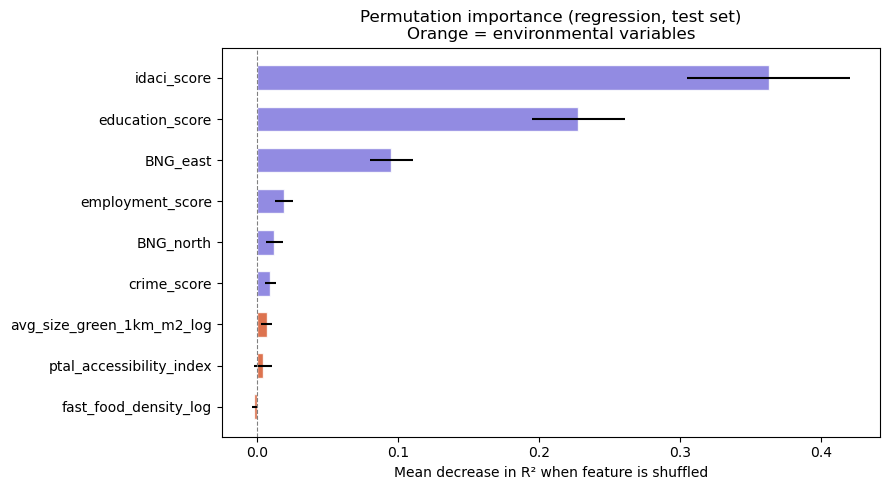

In [12]:
# --- Permutation importance (regression model on test set) ---
perm_imp = permutation_importance(
    xgb_reg, X_test, y_reg_test,
    n_repeats=30,
    random_state=42,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'feature'    : FEATURES,
    'importance' : perm_imp.importances_mean,
    'std'        : perm_imp.importances_std
}).sort_values('importance', ascending=False)

print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#D85A30' if 'fast_food' in f or 'green' in f or 'ptal' in f else '#7F77DD'
          for f in perm_df['feature']]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors, alpha=0.85,
        edgecolor='white', height=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean decrease in R² when feature is shuffled')
ax.set_title('Permutation importance (regression, test set)\nOrange = environmental variables')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

<figure id="fig-perm-importance">
<figcaption style="font-size: 0.85em; color: gray">
<strong>Figure 3:</strong>  Permutation importance scores showing mean decrease in R² when each feature is shuffled. Orange bars indicate the three environmental predictors. Error bars show standard deviation across 30 repeats.
</figcaption>
</figure>

#### 4.4.2 Partial Dependence Plots (PDP)

PDPs show marginal effects of features on predicted obesity rate after averaging all other features. This isolates relationships between environmental predictors and the outcome, showing how the relationship behaves and in which direction. 

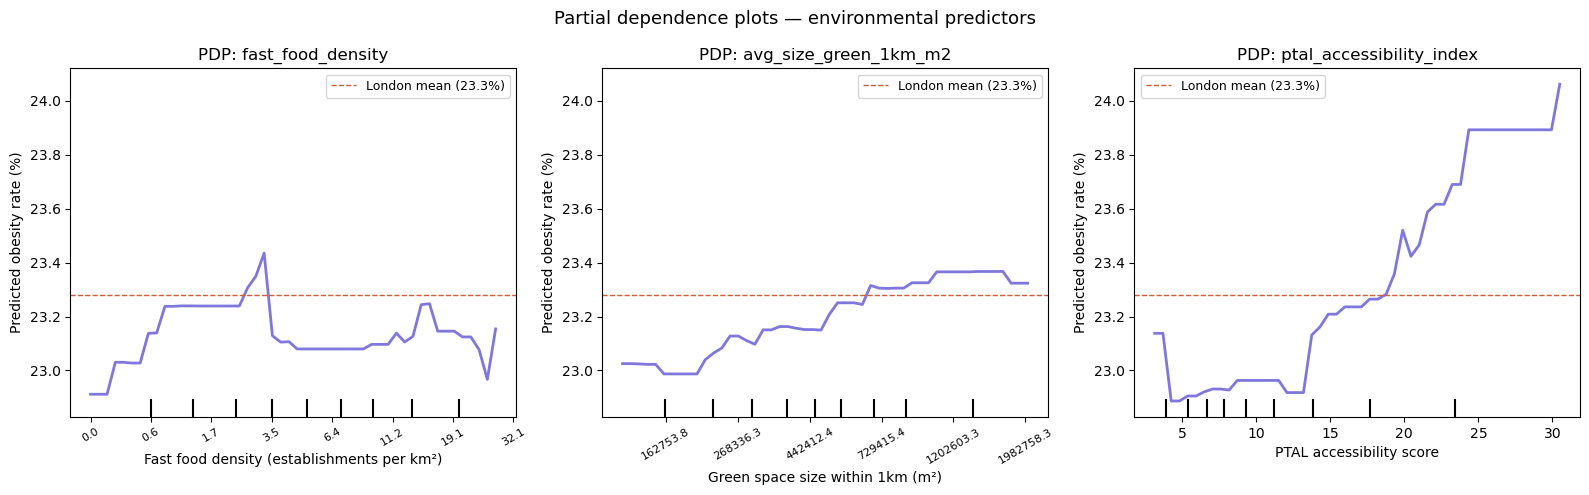

In [13]:
# --- Partial Dependence Plots ---
env_features = ['fast_food_density_log', 'avg_size_green_1km_m2_log', 'ptal_accessibility_index']
env_idx      = [FEATURES.index(f) for f in env_features]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Partial dependence plots — environmental predictors', fontsize=13)

PartialDependenceDisplay.from_estimator(
    xgb_reg, X_train, features=env_idx,
    feature_names=FEATURES,
    ax=axes, grid_resolution=50,
    line_kw={'color': '#7F77DD', 'linewidth': 2}
)

x_labels = {
    'fast_food_density_log'     : 'Fast food density (establishments per km²)',
    'avg_size_green_1km_m2_log' : 'Green space size within 1km (m²)',
    'ptal_accessibility_index'  : 'PTAL accessibility score'
}

for ax, feat in zip(axes, env_features):
    ax.set_title(f'PDP: {feat.replace("_log", "")}')
    ax.set_ylabel('Predicted obesity rate (%)')
    ax.axhline(y_reg.mean(), color='#D85A30', linewidth=1, linestyle='--', label=f'London mean ({y_reg.mean():.1f}%)')
    ax.legend(fontsize=9)
    ax.set_xlabel(x_labels[feat])

    # Back-transform log features to original units
    if '_log' in feat:
        log_ticks = ax.get_xticks()
        original_ticks = np.expm1(log_ticks)
        ax.set_xticklabels([f'{v:.1f}' for v in original_ticks], rotation=30, fontsize=8)

plt.tight_layout()
plt.show()

<figure id="fig-pdp">
<figcaption style="font-size: 0.85em; color: gray">
<strong>Figure 4:</strong> Partial dependence plots showing the marginal effect of each environmental predictor on predicted obesity rate. Log-transformed features are converted back to original units on the x-axis. The London mean (23.3%) is shown for reference.
</figcaption>
</figure>

### 4.5 Spatial k-fold cross-validation

Random CV is inappropriate for spatial data as nearby MSOAs share characteristics, which in both train and test folds leak information and inflate estimates (Pohjankukka et al., 2017).

Spatial k-fold CV partitions MSOAs into geographical blocks using k-means on coordinates, ensuring the model is tested on unseen areas during training. The gap between random and spatial CV R² quantifies how much spatial autocorrelation inflates performance.

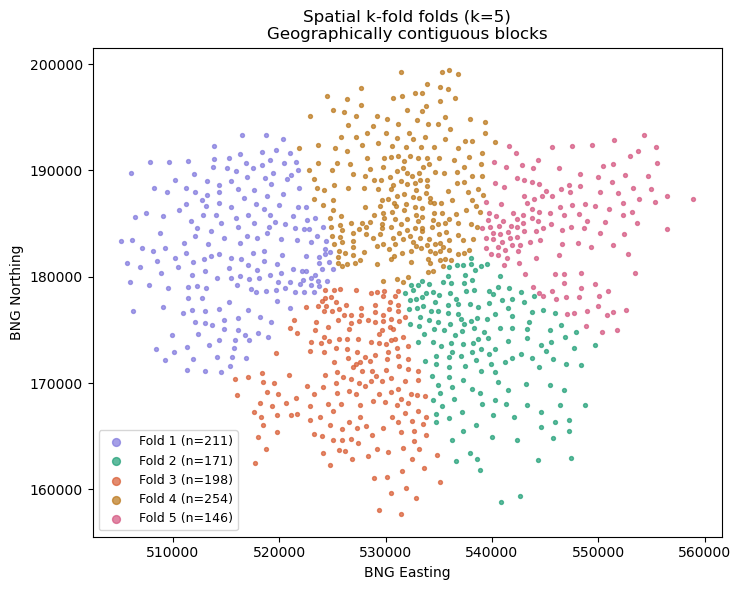

In [14]:
# --- Build spatial folds using k-means on BNG coordinates ---
# N_FOLDS = 5 as balances sufficient training data per fold (~784 MSOAs) with meaningful 
# geographic separation between blocks
N_FOLDS = 5  

coords   = df[['BNG_east', 'BNG_north']].values
kmeans   = KMeans(n_clusters=N_FOLDS, random_state=42, n_init=10)
spatial_fold_labels = kmeans.fit_predict(coords)

# Visualise the spatial folds
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517', '#D4537E']
for fold_id in range(N_FOLDS):
    mask = spatial_fold_labels == fold_id
    ax.scatter(
        df.loc[mask, 'BNG_east'],
        df.loc[mask, 'BNG_north'],
        s=8, alpha=0.7, color=palette[fold_id],
        label=f'Fold {fold_id + 1} (n={mask.sum()})'
    )
ax.set_title(f'Spatial k-fold folds (k={N_FOLDS})\nGeographically contiguous blocks')
ax.set_xlabel('BNG Easting')
ax.set_ylabel('BNG Northing')
ax.set_aspect('equal')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

  Fold 1: RMSE=3.279  R²=0.661
  Fold 2: RMSE=3.763  R²=0.688
  Fold 3: RMSE=3.884  R²=0.604
  Fold 4: RMSE=4.620  R²=0.473
  Fold 5: RMSE=3.323  R²=0.513

Spatial CV — Mean RMSE: 3.774 ± 0.485
Spatial CV — Mean R²  : 0.588 ± 0.083
Random CV  — R²       : 0.693  (from Phase 3 random split)

R² gap (random - spatial): 0.105


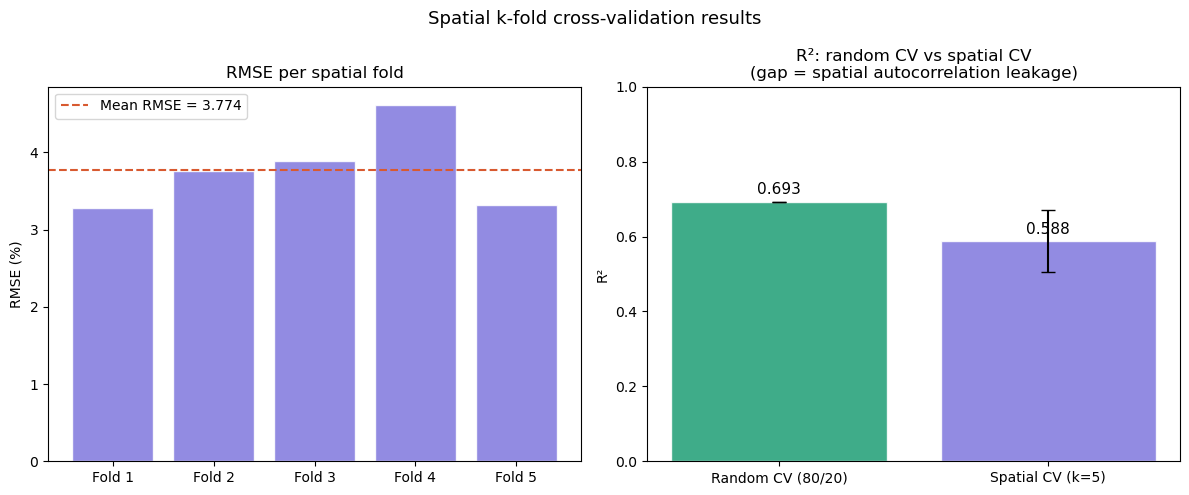

In [15]:
# --- Spatial CV — regression ---
X_all = df[FEATURES]

spatial_rmse = []
spatial_r2   = []

for fold_id in range(N_FOLDS):
    test_mask  = spatial_fold_labels == fold_id
    train_mask = ~test_mask

    X_tr, X_te = X_all[train_mask], X_all[test_mask]
    y_tr, y_te = y_reg[train_mask], y_reg[test_mask]

    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model.fit(X_tr, y_tr, verbose=False)
    y_pred = model.predict(X_te)

    spatial_rmse.append(np.sqrt(mean_squared_error(y_te, y_pred)))
    spatial_r2.append(r2_score(y_te, y_pred))
    print(f'  Fold {fold_id+1}: RMSE={spatial_rmse[-1]:.3f}  R²={spatial_r2[-1]:.3f}')

print(f'\nSpatial CV — Mean RMSE: {np.mean(spatial_rmse):.3f} ± {np.std(spatial_rmse):.3f}')
print(f'Spatial CV — Mean R²  : {np.mean(spatial_r2):.3f} ± {np.std(spatial_r2):.3f}')
print(f'Random CV  — R²       : {r2:.3f}  (from Phase 3 random split)')
print(f'\nR² gap (random - spatial): {r2 - np.mean(spatial_r2):.3f}')

# --- Spatial CV performance visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Spatial k-fold cross-validation results', fontsize=13)

fold_labels = [f'Fold {i+1}' for i in range(N_FOLDS)]

axes[0].bar(fold_labels, spatial_rmse, color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].axhline(np.mean(spatial_rmse), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Mean RMSE = {np.mean(spatial_rmse):.3f}')
axes[0].set_ylabel('RMSE (%)')
axes[0].set_title('RMSE per spatial fold')
axes[0].legend()

# --- Compare random vs spatial CV ---
methods = ['Random CV (80/20)', 'Spatial CV (k=5)']
r2_vals = [r2, np.mean(spatial_r2)]
r2_errs = [0, np.std(spatial_r2)]
colors  = ['#1D9E75', '#7F77DD']
axes[1].bar(methods, r2_vals, yerr=r2_errs, color=colors,
            alpha=0.85, edgecolor='white', capsize=5)
axes[1].set_ylabel('R²')
axes[1].set_title('R²: random CV vs spatial CV\n(gap = spatial autocorrelation leakage)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

<figure id="fig-spatial-cv">
<figcaption style="font-size: 0.85em; color: gray">
<strong>Figure 5:</strong> Spatial k-fold cross-validation results showing RMSE per fold and comparison between random CV R² (0.693) and spatial CV R² (0.588), with the gap of 0.105 quantifying spatial autocorrelation leakage.
</figcaption>
</figure>

## 5. Results and discussion

### 5.1 Regression results ([Task A](#431-task-a---xgboost-regression))

The XGBoost regression explained 69.3% of variance in obesity rates across London (R²=0.693, RMSE=3.343pp, MAE=2.621pp). The model captures meaningful spatial variation in obesity risk, although the remaining 30.7% unexplained variance reflects a sizable gap in the model, likely explained by individual level factors including dietary behaviour and physical activity.

### 5.2 Classification results ([Task B](#432-task-b---xgboost-classification))

The classifier correctly identified the extreme MSOA in 86.2% of cases when comparing a random extreme MSOA against a random normal one (ROC-AUC=0.862). At the optimal threshold (0.61), the model identified 13 of 20 extreme MSOAs (recall=0.65), with 21 false positives (precision=0.37). The threshold sits close to the default 0.50 indicating well calibrated outputs. 

This precision-recall trade-off is reflected in the moderate F1 (0.473) and MCC (0.415) scores which are a consequence of the 9:1 class imbalance. There are few genuine extreme cases in the training data so the model's decision boundary remains uncertain despite SMOTE. The model is best as a screening tool for identifying candidate extreme MSOAs rather than as a definitive decision-making tool.

### 5.3 Feature importance and partial dependence

Deprivation dominates predictions ([Figure 3](#fig-perm-importance)) with `idaci_score` (Δ R²=0.363) and `education_score` (Δ R²=0.228) the strongest predictors, confirming socio-economic deprivation as the primary driver of obesity variation across London.

All three environmental predictors return near-zero importance with error bars overlapping zero, `fast_food_density_log` (Δ R²=−0.002), `avg_size_green_1km_m2_log` (Δ R²=0.007) and `ptal_accessibility_index` (Δ R²=0.004). This directly addresses the research question, environmental factors contribute no independent predictive capabilities once controlled for deprivation. The association with obesity is mediated through deprivation rather than representing a genuine environmental effect.

PDP ([Figure 4](#fig-pdp)) confirms the findings with predicted obesity varying by less than 0.5 percentage points across the observed range of `fast_food_density` and `avg_size_green_1km_m2`, well within natural variations across MSOAs (SD=6.3pp). PTAL shows a larger range (~1.0pp) but in a counterintuitive positive direction, likely reflecting the correlation with inner city deprivation rather than genuine transport-obesity link.

### 5.4 Spatial cross-validation

Spatial CV returned mean R² of 0.588±0.083 ([Figure 5](#fig-spatial-cv)), a gap of 0.105 below the random split estimate (0.693), confirming spatial autocorrelation inflating model performance. The spatial CV result is the more honest estimate of generalisation to new geographic areas.

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

Analysis applied supervised machine learning at MSOA level to examine whether environmental factors — fast food density, green space and public transport accessibility — independently predict child obesity rates across London once socio-economic deprivation is controlled for. All three returned near-zero permutation importance once deprivation and geography were accounted for, with PDP confirming negligible effects. Socio-economic deprivation, particularly IDACI and educational deprivation was the dominant predictor. The spatial cross-validation R² (0.588) indicates meaningful variation is captured, although substantial unexplained variance exists likely reflecting individual level factors. The classification model offers a tool for identifying candidate extreme MSOAs for further investigation rather than serving as a standalone decision-making tool although even then further model refinement would be beneficial first.

Two limitations are worth noting. The area-level characteristics cannot distinguish whether environmental effects are absent or simply operating at a finer scale than MSOAs. Green space and fast food measures are also crude, for example proximity to parks does not capture its quality or usability.

Future work could incorporate finer grained environmental measures, incorporate temporal change, or apply graph neural networks using spatial adjacency to model spillover between neighbouring areas.

## 7. References

[[ go back to the top ]](#Table-of-contents)

Breiman, Leo. ‘Random Forests’. Machine Learning 45, no. 1 (2001): 5–32. https://doi.org/10.1023/A:1010933404324.

Burgoine, Thomas, Nita Forouhi, Simon Griffin, Nicholas Wareham, and Pablo Monsivais. ‘Associations between Exposure to Takeaway Food Outlets, Takeaway Food Consumption, and Body Weight in Cambridgeshire, UK: Population Based, Cross Sectional Study’. BMJ (Clinical Research Ed.) 348 (March 2014): g1464. https://doi.org/10.1136/bmj.g1464.

Chawla, N. V., K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer. ‘SMOTE: Synthetic Minority Over-Sampling Technique’. Journal of Artificial Intelligence Research 16 (June 2002): 321–57. https://doi.org/10.1613/jair.953.

Chen, Tianqi, and Carlos Guestrin. ‘XGBoost: A Scalable Tree Boosting System’. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (New York, NY, USA), KDD ’16, 13 August 2016, 785–94. https://doi.org/10.1145/2939672.2939785.

Jia, Peng, Xinxi Cao, Hongxi Yang, et al. ‘Green Space Access in the Neighbourhood and Childhood Obesity’. Obesity Reviews 22 (July 2020). https://doi.org/10.1111/obr.13100.

NHS England. ‘National Child Measurement Programme, England, 2023/24 School Year’. NHS England Digital, 2025. https://digital.nhs.uk/data-and-information/publications/statistical/national-child-measurement-programme/2023-24-school-year.

Rahilly, John, Mario Cortina-Borja, and Oliver Mytton. ‘Trends in Childhood Obesity for Upper Tier Local Authorities in England between 2007/08 and 2023/24: A Latent Trajectory Analysis’. Journal of Public Health (Oxford, England) 47, no. 4 (2025): e668–77. https://doi.org/10.1093/pubmed/fdaf103.

Page, Angie S., Ashley R. Cooper, Pippa Griew, and Russell Jago. ‘Independent Mobility, Perceptions of the Built Environment and Children’s Participation in Play, Active Travel and Structured Exercise and Sport: The PEACH Project’. The International Journal of Behavioral Nutrition and Physical Activity 7 (February 2010): 17. https://doi.org/10.1186/1479-5868-7-17.

Pohjankukka, Jonne, Tapio Pahikkala, Paavo Nevalainen, and Jukka Heikkonen. ‘Estimating the Prediction Performance of Spatial Models via Spatial K-Fold Cross Validation’. International Journal of Geographical Information Science 31, no. 10 (2017): 2001–19. https://doi.org/10.1080/13658816.2017.1346255.

Xu, Fei, Lingling Jin, Zhenzhen Qin, et al. ‘Access to Public Transport and Childhood Obesity: A Systematic Review’. Obesity Reviews 22 (January 2020). https://doi.org/10.1111/obr.12987.
